In [70]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor

# Wczytanie danych oraz wstępna analiza danych
### Celem pierwszego etapu jest wczytanie danych oraz przeprowadzenie wstępnej analizy eksploracyjnej (EDA). Pozwala ona zrozumieć strukturę danych, sprawdzić typy zmiennych, występowanie braków danych oraz podstawowe statystyki opisowe.

In [54]:
df = pd.read_csv('Sample.csv', sep=';')

df.head()

,Parametr_a,Parametr_b,Parametr_c,Parametr_d,Parametr_e,Parametr_f,Parametr_g,Parametr_h,Parametr_i,Parametr_j,Parametr_k,Zmienna_Y
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [55]:
df.isna().sum()

Parametr_a    0
Parametr_b    0
Parametr_c    0
Parametr_d    0
Parametr_e    0
Parametr_f    0
Parametr_g    0
Parametr_h    0
Parametr_i    0
Parametr_j    0
Parametr_k    0
Zmienna_Y     0
dtype: int64

### W zbiorze danych nie występują brakujące wartości, dlatego nie było konieczności stosowania metod imputacji.

In [56]:
df.dtypes

Parametr_a    float64
Parametr_b    float64
Parametr_c    float64
Parametr_d    float64
Parametr_e    float64
Parametr_f    float64
Parametr_g    float64
Parametr_h    float64
Parametr_i    float64
Parametr_j    float64
Parametr_k    float64
Zmienna_Y       int64
dtype: object

In [57]:
df.describe()

,Parametr_a,Parametr_b,Parametr_c,Parametr_d,Parametr_e,Parametr_f,Parametr_g,Parametr_h,Parametr_i,Parametr_j,Parametr_k,Zmienna_Y
count,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000
mean,6.854788,0.278241,0.334192,6.391415,0.045772,35.308085,138.360657,0.994027,3.188267,0.489847,10.514267,5.877909
std,0.843868,0.100795,0.121020,5.072058,0.021848,17.007137,42.498065,0.002991,0.151001,0.114126,1.230621,0.885639
min,3.800000,0.080000,0.000000,0.600000,0.009000,2.000000,9.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.300000,0.210000,0.270000,1.700000,0.036000,23.000000,108.000000,0.991723,3.090000,0.410000,9.500000,5.000000
50%,6.800000,0.260000,0.320000,5.200000,0.043000,34.000000,134.000000,0.993740,3.180000,0.470000,10.400000,6.000000
75%,7.300000,0.320000,0.390000,9.900000,0.050000,46.000000,167.000000,0.996100,3.280000,0.550000,11.400000,6.000000
max,14.200000,1.100000,1.660000,65.800000,0.346000,289.000000,440.000000,1.038980,3.820000,1.080000,14.200000,9.000000


#### Statystyki opisowe pokazują zakres oraz rozkład zmiennych. 
#### Zmienna zależna `Zmienna_Y` przyjmuje wartości w przedziale od 3 do 9, przy czym większość obserwacji koncentruje się w okolicach wartości 5-6.

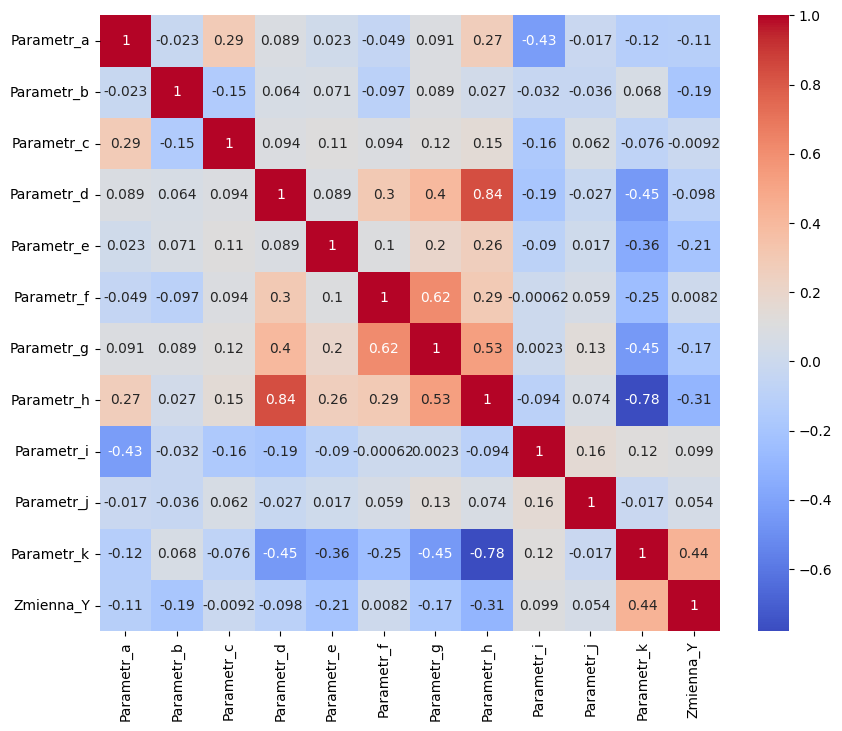

In [58]:
corr = df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

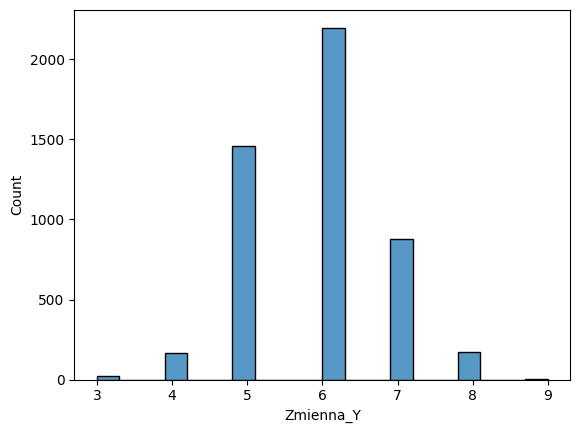

In [59]:
sns.histplot(df["Zmienna_Y"], bins=20)
plt.show()

In [60]:
X = df.drop("Zmienna_Y", axis=1)
y = df["Zmienna_Y"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#### Dane zostały podzielone na zbiór treningowy (80%) oraz testowy (20%).
#### Zbiór treningowy służy do uczenia modeli, natomiast zbiór testowy do oceny jakości predykcji na nowych danych.

# Budowa modeli predykcyjnych
## a) regresja liniowa

In [61]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Zastosowano standaryzację zmiennych przy użyciu StandardScaler.
#### Jest to szczególnie istotne w przypadku regresji liniowej, ponieważ zmienne o różnych skalach mogą wpływać na stabilność estymacji modelu. Sugerując się tabelą ze statystykami opisowymi, rozbieżność osiąganych wartości pomiędzy parametrami potrafi być znacząca.

In [62]:
lin_model = LinearRegression()
lin_model.fit(X_train_scaled, y_train)

LinearRegression()

In [66]:
y_pred_lin = lin_model.predict(X_test_scaled)
rmse_lin = np.sqrt(mean_squared_error(y_test, y_pred_lin))
r2_lin = r2_score(y_test, y_pred_lin)

print(rmse_lin, r2_lin)

0.754337306334198 0.26527500421196537


### Model regresji liniowej osiągnął RMSE ≈ 0.75 oraz R² ≈ 0.27.

### Oznacza to, że model wyjaśnia około 27% wariancji zmiennej zależnej. 
### Średni błąd predykcji wynosi około 0.75 jednostki zmiennej Y.

## b) Dummy Regressor

### W celu oceny jakości modelu wykorzystałem również model bazowy (Dummy Regressor), który przewiduje średnią wartość zmiennej zależnej.
### Pozwala to sprawdzić, czy zastosowane modele predykcyjne rzeczywiście poprawiają jakość predykcji w stosunku do prostego podejścia bazowego.

In [67]:
dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train_scaled, y_train)

y_pred_dummy = dummy.predict(X_test_scaled)

rmse_dummy = np.sqrt(mean_squared_error(y_test, y_pred_dummy))

print(rmse_dummy)

0.8806495608493429


### Porównanie z modelem bazowym pozwala ocenić, czy model predykcyjny rzeczywiście wykorzystuje informacje zawarte w zmiennych objaśniających.
### Model bazowy osiągnął RMSE = 0.88, natomiast regresja liniowa uzyskała RMSE = 0.75. Oznacza to, że model regresji liniowej poprawia jakość predykcji o około 14% w stosunku do prostego modelu bazowego.



## c) Random Forest

### Model ten dobrze radzi sobie z nieliniowymi zależnościami między zmiennymi oraz jest odporny na korelacje między zmiennymi objaśniającymi.

In [72]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [73]:
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(rmse_rf, r2_rf)

0.5876840137352725 0.5540549002156483


### Model Random Forest osiągnął RMSE ≈ 0.59 oraz R² ≈ 0.55.

### W porównaniu z regresją liniową oznacza to znaczącą poprawę jakości predykcji. 
### Model wyjaśnia ponad 55% wariancji zmiennej zależnej i osiąga wyraźnie niższy błąd predykcji.

# Wybór modelu końcowego

W celu porównania jakości predykcji zastosowano trzy modele:

- model bazowy (Dummy Regressor),
- regresję liniową,
- Random Forest.

Porównanie wyników:

| Model | RMSE | R² |
|------|------|------|
| Dummy Regressor | 0.88 | - |
| Linear Regression | 0.75 | 0.27 |
| Random Forest | 0.59 | 0.55 |

Najlepsze wyniki uzyskał model Random Forest, który osiągnął najniższy błąd predykcji (RMSE) oraz najwyższą wartość współczynnika determinacji R².

Wyniki sugerują, że zależności pomiędzy zmiennymi objaśniającymi a zmienną zależną mają charakter częściowo nieliniowy, dlatego modele drzew decyzyjnych lepiej opisują strukturę danych.

Z tego względu Random Forest jest najrozsądniejszym wyborem jako model końcowy.